<a href="https://colab.research.google.com/github/Codersweta7/Codersweta7/blob/main/5view_shape_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Shape Detector — 5 View Analysis
### Top + Bottom + 3 Side views se shapes detect karo
**Detects:** Circle, Ellipse, Semicircle, Triangle, Rectangle, Square, Pentagon, Hexagon, Other  
**Calculates:** Area, Perimeter, Diameter, Radius, Formula
---

In [ ]:
# Install required libraries
!pip install opencv-python-headless matplotlib numpy pandas scipy -q

   OBJECT SHAPE DETECTOR — 5 VIEW ANALYSIS

Upload karo 5 images in this order:
  1. Top view
  2. Bottom view
  3. Side view 1 (Front)
  4. Side view 2 (Left/Right)
  5. Side view 3 (Back)


--- Top view upload karo ---


Saving top.jpg to top.jpg
  Loaded: top.jpg  (1069x647 px)

--- Bottom view upload karo ---


Saving bottom.jpg to bottom (1).jpg
  Loaded: bottom (1).jpg  (973x989 px)

--- Side-Front view upload karo ---


Saving side1.jpg to side1 (1).jpg
  Loaded: side1 (1).jpg  (4096x634 px)

--- Side-Left view upload karo ---


Saving side1.jpg to side1 (2).jpg
  Loaded: side1 (2).jpg  (4096x634 px)

--- Side-Back view upload karo ---


Saving side (2).jpg to side (2).jpg
  Loaded: side (2).jpg  (4096x634 px)

✅ 5 views loaded successfully!

Analyzing: Top view...
  Found 0 shape(s)

Analyzing: Bottom view...
  Found 34 shape(s)

Analyzing: Side-Front view...
  Found 10 shape(s)

Analyzing: Side-Left view...
  Found 10 shape(s)

Analyzing: Side-Back view...
  Found 10 shape(s)

Total shapes detected across all views: 64

          SHAPE DETECTION RESULTS — ALL VIEWS

─────────────────────────────────────────────────────────────────
  VIEW: Bottom
─────────────────────────────────────────────────────────────────

  Shape #100: Circle (Hough)
    Circularity   : 1.0
    Area          : 73541.5 px²
    Perimeter     : 961.3 px
    Bounding Box  : 306 x 306 px
    Diameter      : 306 px
    Radius        : 153 px
    Formula       : pi * r^2

  Shape #101: Circle (Hough)
    Circularity   : 1.0
    Area          : 66966.2 px²
    Perimeter     : 917.3 px
    Bounding Box  : 292 x 292 px
    Diameter      : 292 px
    Radi

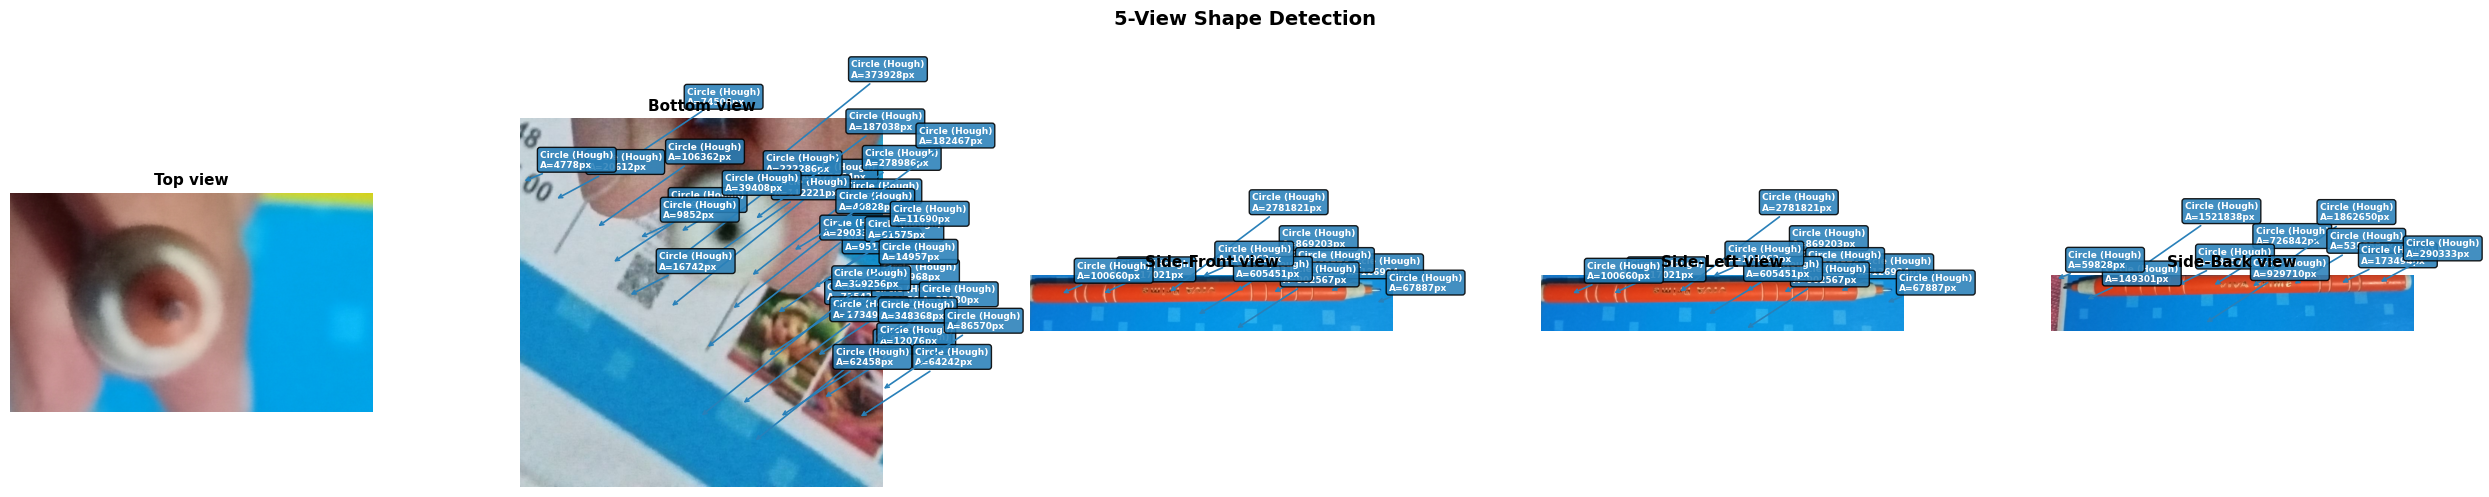

Image saved: results/5view_annotated.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads starting...


In [ ]:
# ============================================================
# OBJECT SHAPE DETECTOR - 5 View Input (Top, Bottom, Side x3)
# Detects shapes per view: Circle, Ellipse, Semicircle, Rectangle, Triangle, Other
# Calculates: Area, Perimeter, Diameter, Surface Area, Volume
# ============================================================

import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
from google.colab import files
from IPython.display import display

PI = math.pi

# ============================================================
# STEP 1: Upload 5 view images
# ============================================================

print("=" * 60)
print("   OBJECT SHAPE DETECTOR — 5 VIEW ANALYSIS")
print("=" * 60)
print("""
Upload karo 5 images in this order:
  1. Top view
  2. Bottom view
  3. Side view 1 (Front)
  4. Side view 2 (Left/Right)
  5. Side view 3 (Back)
""")

view_names = ["Top", "Bottom", "Side-Front", "Side-Left", "Side-Back"]
view_images = {}

for view in view_names:
    print(f"\n--- {view} view upload karo ---")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    img = cv2.imread(fname)
    if img is None:
        print(f"  WARNING: {fname} is not loading , skip.")
        continue
    view_images[view] = {"path": fname, "img": img}
    print(f"  Loaded: {fname}  ({img.shape[1]}x{img.shape[0]} px)")

print(f"\n {len(view_images)} views loaded successfully!")

# ============================================================
# STEP 2: Shape Detection & Measurement Functions
# ============================================================

def detect_shapes_in_view(img, view_name):
    """
    Ek view image mein shapes detect karo.
    Returns list of detected shape dicts.
    """
    H, W = img.shape[:2]
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Adaptive threshold for better edge detection
    thresh = cv2.adaptiveThreshold(blurred, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 11, 2)

    # Morphological cleanup
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Edge detection
    edges = cv2.Canny(blurred, 30, 120)
    edges = cv2.dilate(edges, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter & sort by area
    min_area = (W * H) * 0.005   # at least 0.5% of image
    valid = []
    for c in contours:
        a = float(cv2.contourArea(c))
        if a > min_area:
            valid.append((a, c))
    valid.sort(key=lambda x: x[0], reverse=True)

    # Scale: assume object fills ~70% of image
    # We'll report in pixels and also relative %
    results = []
    for rank, (area_px, c) in enumerate(valid[:5]):
        x, y, w, h = cv2.boundingRect(c)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)
        n_vertices = len(approx)

        circularity = (4 * PI * area_px / (peri ** 2)) if peri > 0 else 0
        aspect_ratio = float(w) / h if h > 0 else 0
        extent = area_px / (w * h) if w * h > 0 else 0

        shape_type, shape_info = classify_shape(c, n_vertices, circularity, aspect_ratio, area_px, peri, w, h)

        results.append({
            "view"         : view_name,
            "rank"         : rank + 1,
            "shape"        : shape_type,
            "area_px"      : round(area_px, 1),
            "perimeter_px" : round(peri, 1),
            "width_px"     : w,
            "height_px"    : h,
            "circularity"  : round(circularity, 3),
            "aspect_ratio" : round(aspect_ratio, 3),
            "vertices"     : n_vertices,
            "contour"      : c,
            "bbox"         : (x, y, w, h),
            **shape_info
        })

    # Also try Hough circles separately
    hough = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2,
                             minDist=int(W * 0.1),
                             param1=60, param2=25,
                             minRadius=int(W * 0.03),
                             maxRadius=int(W * 0.45))
    if hough is not None:
        for i, (cx, cy, r) in enumerate(np.round(hough[0]).astype(int)):
            area_px = PI * r * r
            peri    = 2 * PI * r
            results.append({
                "view"         : view_name,
                "rank"         : 100 + i,
                "shape"        : "Circle (Hough)",
                "area_px"      : round(area_px, 1),
                "perimeter_px" : round(peri, 1),
                "width_px"     : r * 2,
                "height_px"    : r * 2,
                "circularity"  : 1.0,
                "aspect_ratio" : 1.0,
                "vertices"     : 0,
                "contour"      : None,
                "bbox"         : (int(cx - r), int(cy - r), r * 2, r * 2),
                "diameter_px"  : r * 2,
                "radius_px"    : r,
                "formula"      : "pi * r^2",
                "extra"        : {}
            })

    return results


def classify_shape(c, n_vert, circ, aspect, area_px, peri, w, h):
    """
    Shape classify karo aur measurements nikalo.
    Returns (shape_name, info_dict)
    """
    info = {}

    # CIRCLE
    if circ > 0.80:
        r = math.sqrt(area_px / PI)
        info = {
            "diameter_px" : round(r * 2, 1),
            "radius_px"   : round(r, 1),
            "formula"     : "pi * r^2",
            "extra"       : {"circumference_px": round(2 * PI * r, 1)}
        }
        return "Circle", info

    # ELLIPSE
    if circ > 0.55 and aspect > 0.3 and aspect < 1.8:
        a = w / 2
        b = h / 2
        area_e = PI * a * b
        approx_peri = 2 * PI * math.sqrt((a**2 + b**2) / 2)
        info = {
            "diameter_px" : round(max(w, h), 1),
            "radius_px"   : round(max(a, b), 1),
            "formula"     : "pi * a * b",
            "extra"       : {
                "major_axis_px": round(max(w, h), 1),
                "minor_axis_px": round(min(w, h), 1),
                "approx_perimeter_px": round(approx_peri, 1)
            }
        }
        return "Ellipse", info

    # SEMICIRCLE
    if circ > 0.35 and circ <= 0.70 and (aspect > 1.5 or aspect < 0.7):
        r = max(w, h) / 2
        area_s = (PI * r * r) / 2
        info = {
            "diameter_px" : round(r * 2, 1),
            "radius_px"   : round(r, 1),
            "formula"     : "(pi * r^2) / 2",
            "extra"       : {"perimeter_formula": "pi*r + 2*r"}
        }
        return "Semicircle", info

    # TRIANGLE
    if n_vert == 3:
        info = {
            "diameter_px" : round(max(w, h), 1),
            "radius_px"   : round(max(w, h) / 2, 1),
            "formula"     : "(base * height) / 2",
            "extra"       : {"base_px": w, "height_px": h}
        }
        return "Triangle", info

    # RECTANGLE / SQUARE
    if n_vert == 4:
        sq = "Square" if abs(aspect - 1.0) < 0.1 else "Rectangle"
        info = {
            "diameter_px" : round(math.sqrt(w**2 + h**2), 1),
            "radius_px"   : round(math.sqrt(w**2 + h**2) / 2, 1),
            "formula"     : "width * height",
            "extra"       : {"width_px": w, "height_px": h, "perimeter_px": round(2*(w+h), 1)}
        }
        return sq, info

    # PENTAGON / HEXAGON
    if n_vert == 5:
        s = peri / 5
        area_p = (peri**2) / (4 * 5 * math.tan(PI / 5))
        info = {
            "diameter_px" : round(max(w, h), 1),
            "radius_px"   : round(max(w, h) / 2, 1),
            "formula"     : "n*s^2 / (4*tan(pi/n))",
            "extra"       : {"side_px": round(s, 1)}
        }
        return "Pentagon", info

    if n_vert == 6:
        s = peri / 6
        info = {
            "diameter_px" : round(max(w, h), 1),
            "radius_px"   : round(max(w, h) / 2, 1),
            "formula"     : "3*sqrt(3)/2 * s^2",
            "extra"       : {"side_px": round(s, 1)}
        }
        return "Hexagon", info

    # OTHER
    info = {
        "diameter_px" : round(math.sqrt(w**2 + h**2), 1),
        "radius_px"   : round(math.sqrt(w**2 + h**2) / 2, 1),
        "formula"     : "Contour area (px²)",
        "extra"       : {}
    }
    return "Other/Irregular", info


# ============================================================
# STEP 3: Run Detection on All 5 Views
# ============================================================

all_results = []

for view_name, vdata in view_images.items():
    print(f"\nAnalyzing: {view_name} view...")
    shapes = detect_shapes_in_view(vdata["img"], view_name)
    all_results.extend(shapes)
    print(f"  Found {len(shapes)} shape(s)")

print(f"\nTotal shapes detected across all views: {len(all_results)}")

# ============================================================
# STEP 4: Print Results Per View
# ============================================================

print("\n" + "=" * 65)
print("          SHAPE DETECTION RESULTS — ALL VIEWS")
print("=" * 65)

for view_name in view_names:
    view_shapes = [r for r in all_results if r["view"] == view_name]
    if not view_shapes:
        continue

    print(f"\n{'─'*65}")
    print(f"  VIEW: {view_name}")
    print(f"{'─'*65}")

    for s in view_shapes:
        print(f"\n  Shape #{s['rank']}: {s['shape']}")
        print(f"    Circularity   : {s['circularity']}")
        print(f"    Area          : {s['area_px']} px²")
        print(f"    Perimeter     : {s['perimeter_px']} px")
        print(f"    Bounding Box  : {s['width_px']} x {s['height_px']} px")
        print(f"    Diameter      : {s.get('diameter_px', 'N/A')} px")
        print(f"    Radius        : {s.get('radius_px', 'N/A')} px")
        print(f"    Formula       : {s.get('formula', 'N/A')}")
        for k, v in s.get('extra', {}).items():
            print(f"    {k:<20}: {v} px")

# ============================================================
# STEP 5: Save CSV
# ============================================================

os.makedirs("results", exist_ok=True)

csv_rows = []
for s in all_results:
    row = {
        "View"          : s["view"],
        "Shape"         : s["shape"],
        "Area_px2"      : s["area_px"],
        "Perimeter_px"  : s["perimeter_px"],
        "Width_px"      : s["width_px"],
        "Height_px"     : s["height_px"],
        "Diameter_px"   : s.get("diameter_px", ""),
        "Radius_px"     : s.get("radius_px", ""),
        "Circularity"   : s["circularity"],
        "Aspect_Ratio"  : s["aspect_ratio"],
        "Formula"       : s.get("formula", ""),
    }
    for k, v in s.get("extra", {}).items():
        row[k] = v
    csv_rows.append(row)

df = pd.DataFrame(csv_rows)
csv_path = "results/5view_shape_measurements.csv"
df.to_csv(csv_path, index=False)
print(f"\n CSV saved: {csv_path}")
print(df[["View","Shape","Area_px2","Diameter_px","Formula"]].to_string(index=False))

# ============================================================
# STEP 6: Visualize — All 5 Views with Annotations
# ============================================================

n_views = len(view_images)
fig, axes = plt.subplots(1, n_views, figsize=(5 * n_views, 5))
if n_views == 1:
    axes = [axes]

shape_colors = {
    "Circle"           : (41,  128, 185),
    "Circle (Hough)"   : (41,  128, 185),
    "Ellipse"          : (83,  74,  183),
    "Semicircle"       : (15,  110, 86),
    "Triangle"         : (186, 117, 23),
    "Rectangle"        : (163, 45,  45),
    "Square"           : (163, 45,  45),
    "Pentagon"         : (153, 60,  86),
    "Hexagon"          : (29,  158, 117),
    "Other/Irregular"  : (95,  94,  90),
}

for ax, (view_name, vdata) in zip(axes, view_images.items()):
    img_draw = cv2.cvtColor(vdata["img"].copy(), cv2.COLOR_BGR2RGB)
    view_shapes = [r for r in all_results if r["view"] == view_name]

    for s in view_shapes:
        color = shape_colors.get(s["shape"], (95, 94, 90))
        if s["contour"] is not None:
            cv2.drawContours(img_draw, [s["contour"]], -1, color, 2)
        x, y, w, h = s["bbox"]
        label = f"{s['shape']}\nA={s['area_px']:.0f}px"
        ax.annotate(label,
                    xy=(x + w//2, y + h//2),
                    xytext=(x + w + 10, y),
                    fontsize=6.5, color="white", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3",
                              facecolor=[c/255 for c in color],
                              alpha=0.88),
                    arrowprops=dict(arrowstyle="->",
                                   color=[c/255 for c in color],
                                   lw=1.2))

    ax.imshow(img_draw)
    ax.set_title(f"{view_name} view", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("5-View Shape Detection", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
out_img = "results/5view_annotated.png"
plt.savefig(out_img, dpi=150, bbox_inches="tight")
plt.show()
print(f"Image saved: {out_img}")

# ============================================================
# STEP 7: Download Results
# ============================================================

files.download(csv_path)
files.download(out_img)
print("\nDownloads starting...")
